# Setup VeTra

In [ ]:
import os
if not os.path.exists('./VeTra/VeTra.py'):
    !git submodule init && git submodule update

patched = !git -C ./VeTra apply --check ../VeTra.patch
if patched == []:
    !git -C ./VeTra apply ../VeTra.patch

import sys
if not 'VeTra' in sys.path:
    sys.path.append('./VeTra')

if "R_HOME" not in os.environ.keys():
    print('setting R_HOME assuming conda setup')
    os.environ["R_HOME"] = sys.executable.replace('bin/python', 'lib/R')

# Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import rdata
import networkx as nx
from VeTra import VeTra, numpy_cv

# Read data

In [31]:
%%capture

data_name = 'bifurcating'; n_neighbors=16; n_trj = 2
# data_name = 'trifurcating'; n_neighbors=9; n_trj = 3
# data_name = 'double_bifurcating'; n_neighbors=24; n_trj = 3

data = rdata.read_rds(f'./Datasets/{data_name}/dataset.rds')
n_cells, n_genes = data['expression'].Dim

expressions = np.zeros(data['expression'].Dim)
j = 0
for iter, i, x in zip(np.arange(len(data['expression'].i)), data['expression'].i, data['expression'].x): 
    expressions[i, j] = x
    if iter == data['expression'].p[j+1]: j += 1

velocities = np.zeros(data['rna_velocity'].Dim)
j = 0
for iter, i, v in zip(np.arange(len(data['rna_velocity'].i)), data['rna_velocity'].i, data['rna_velocity'].x): 
    velocities[i, j] = v
    if iter == data['rna_velocity'].p[j+1]: j += 1

initial = np.array([list(data['milestone_ids']).index(ms) for ms in data['progressions']['from']])
colors = plt.colormaps['Set1'](initial)

# Extract topological info of differentiation tree

In [32]:
milestone_lengths = [len([ms for ms in data['progressions']['from'] if ms==id]) for id in data['milestone_ids']]
print(data['milestone_ids'])
print(milestone_lengths)
initial_pseudotime = np.zeros_like(milestone_lengths)
id2i = {id:i for i, id in enumerate(data['milestone_ids'])}
for i in range(1, len(id2i)):
    id_from = data['milestone_network'].at[i, 'from']
    id_to = data['milestone_network'].at[i, 'to']
    initial_pseudotime[id2i[id_to]] = initial_pseudotime[id2i[id_from]] + milestone_lengths[id2i[id_from]]
print(initial_pseudotime)
pseudotime = np.array([initial_pseudotime[initial[i]] + p * milestone_lengths[initial[i]] for (i, p) in enumerate(data['progressions']['percentage'])])
pseudotime /= np.max(pseudotime)

# paths from root to leaves in milestone network
T = nx.DiGraph(zip(data['milestone_network']['from'], data['milestone_network']['to']))
r = [n for n in T.nodes if not T.in_degree(n)][0]
paths = [nx.shortest_path(T, r, n)[:-1] for n in T if T.out_degree(n)==0]

['sA' 'sB' 'sBmid' 'sC' 'sD' 'sEndC' 'sEndD']
[124, 27, 165, 102, 82, 0, 0]
[  0 124 151 316 316 418 398]


# Dimension reduction

In [33]:
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap

dimred = PCA(n_components=2)
dimred.fit(expressions)
expressions_2d = dimred.transform(expressions)
velocities_2d = dimred.transform(expressions + velocities) - expressions_2d

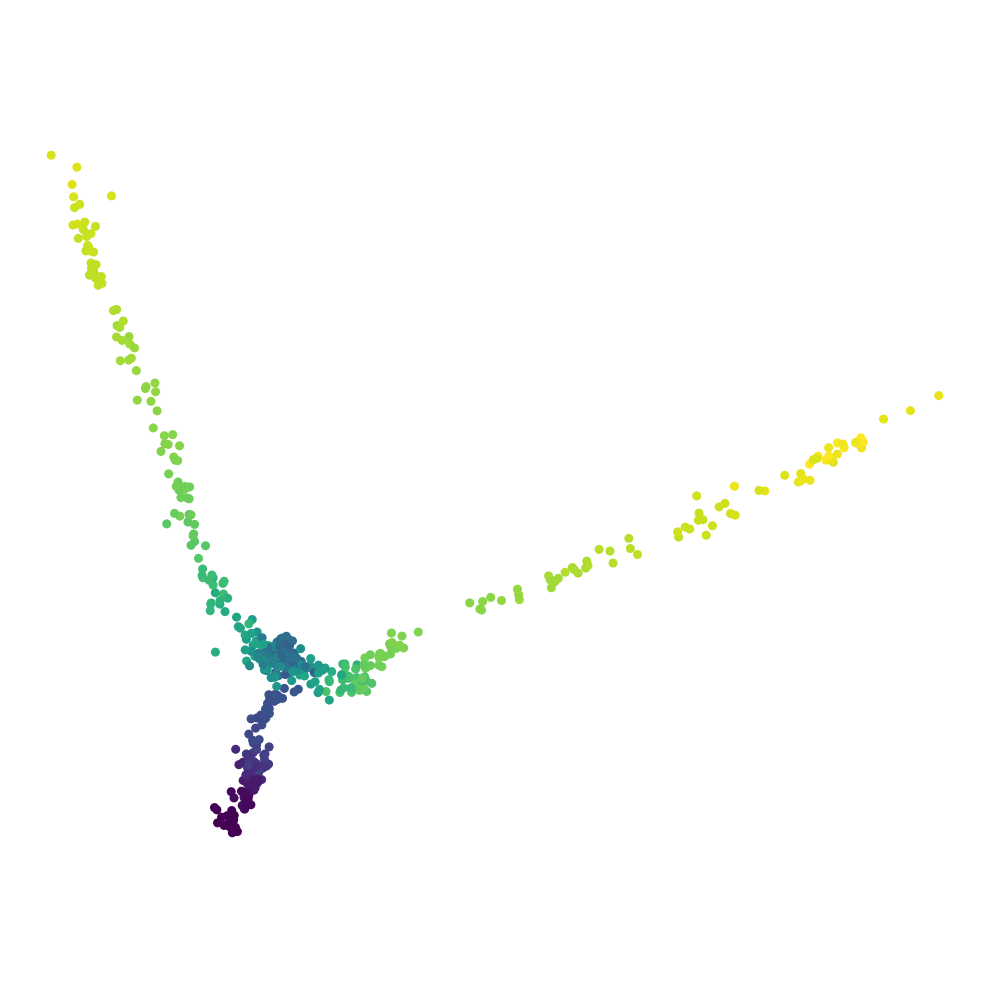

In [34]:
viridis = plt.colormaps['viridis']

fig = plt.figure(figsize=(10, 10))
plt.scatter(expressions_2d[:, 0], expressions_2d[:, 1], color=viridis(pseudotime), s=30, zorder=1)
plt.axis('equal')
plt.axis('off')
fig.tight_layout()

# Run VeTra

Trajectory inference results saved in ./TI_results


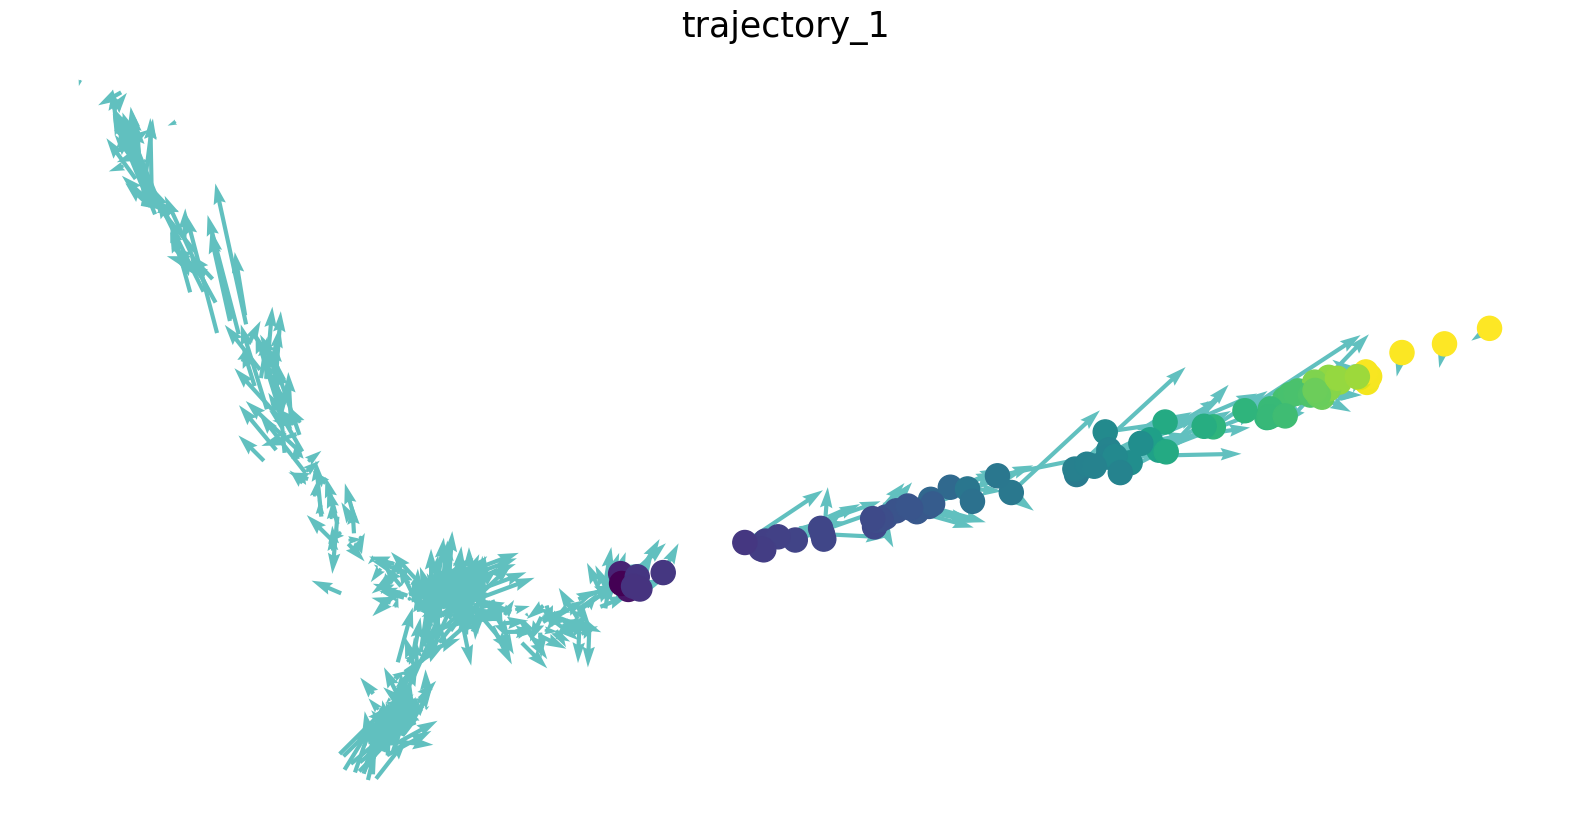

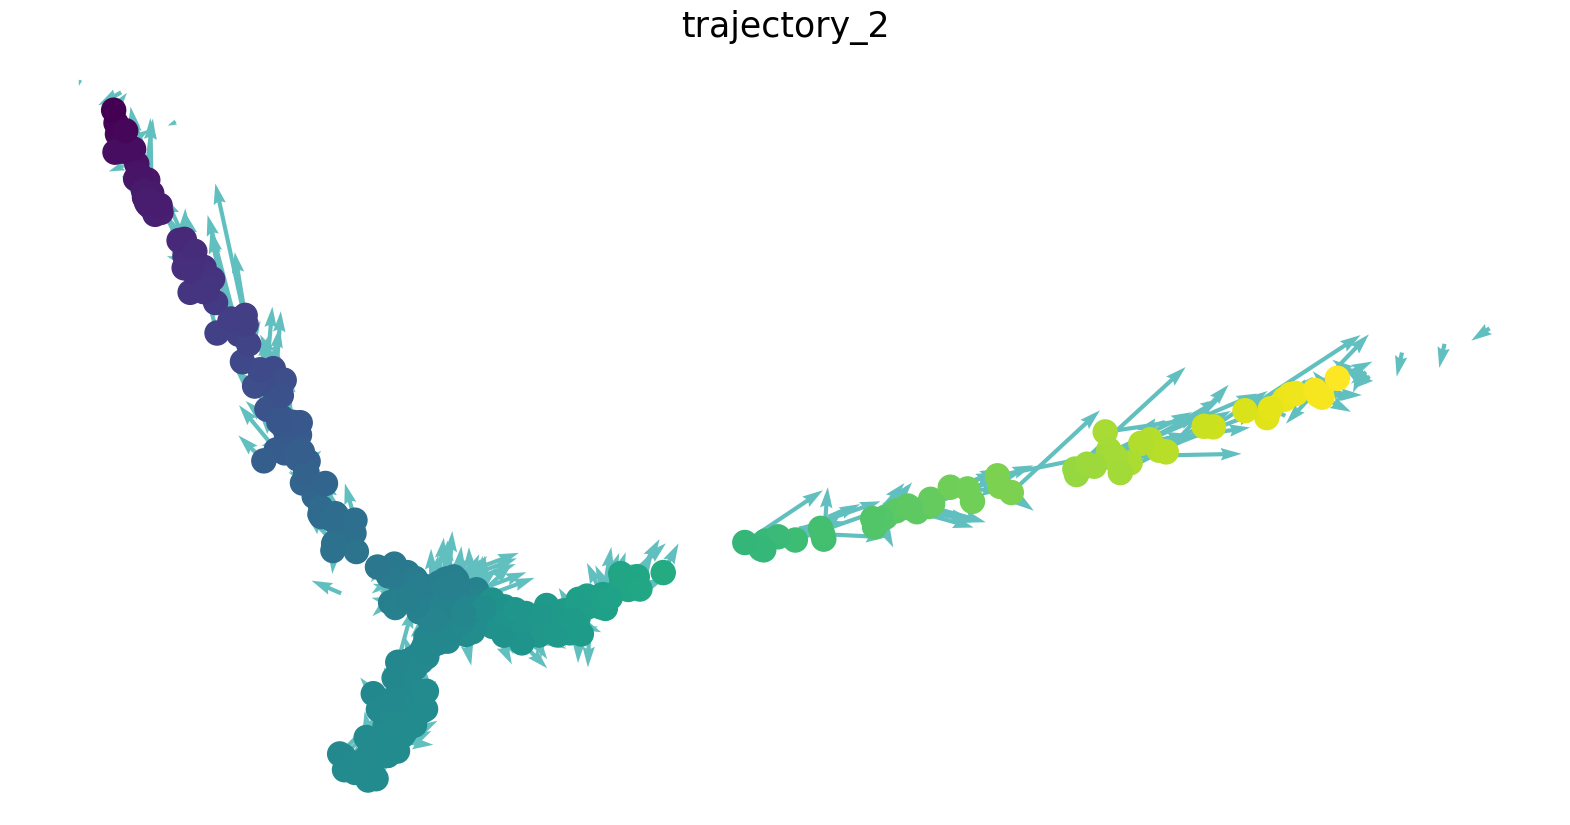

In [35]:
class MyVeTra(VeTra):
    # bypass file I/O
    def __init__(self, x: np.array, v: np.array):
        self.embedding = x
        self.delta_embedding = v

from rpy2.robjects.conversion import localconverterwith localconverter(numpy_cv):    vt = MyVeTra(expressions_2d, velocities_2d)
    vt.vetra(deltaThreshold=12, WCCsizeCutoff=5, clusternumber=n_trj, cosine_thres=0.7, expand=2)

# Compute error in pseudotime

In [36]:
import glob
pseudotime_vetra = np.zeros_like(pseudotime)
paths_vetra = np.zeros((n_cells, n_trj))
n = 0
for i in range(n_trj):
    msk = np.loadtxt(f'cell_select_{i+1}.txt').astype(bool)
    n += np.sum(msk)
    t = np.loadtxt(f'trajectory_{i+1}.txt')
    pseudotime_vetra[msk] = t[msk]
    paths_vetra[:,i] = np.where(msk, t, np.nan)
print(n, len(pseudotime))
# keep NaN if cell not in any path
pseudotime_vetra[~np.isfinite(paths_vetra).any(axis=1)] = np.nan

513 500


In [37]:
per = 0.
for p in paths:
    cells_in_path = [i for i in range(n_cells) if data['progressions']['from'][i+1] in p]

    well_ordered = 0
    for i in cells_in_path:
        for j in cells_in_path:
            if j>i and np.isfinite(pseudotime_vetra[[i,j]]).all() and (pseudotime[i] <= pseudotime[j]) == (pseudotime_vetra[i] <= pseudotime_vetra[j]): well_ordered += 1

    per += well_ordered / (len(cells_in_path)*(len(cells_in_path)-1)/2)

print("average percentage of well-ordered cells:", per / len(paths))

average percentage of well-ordered cells: 0.36343338138959397


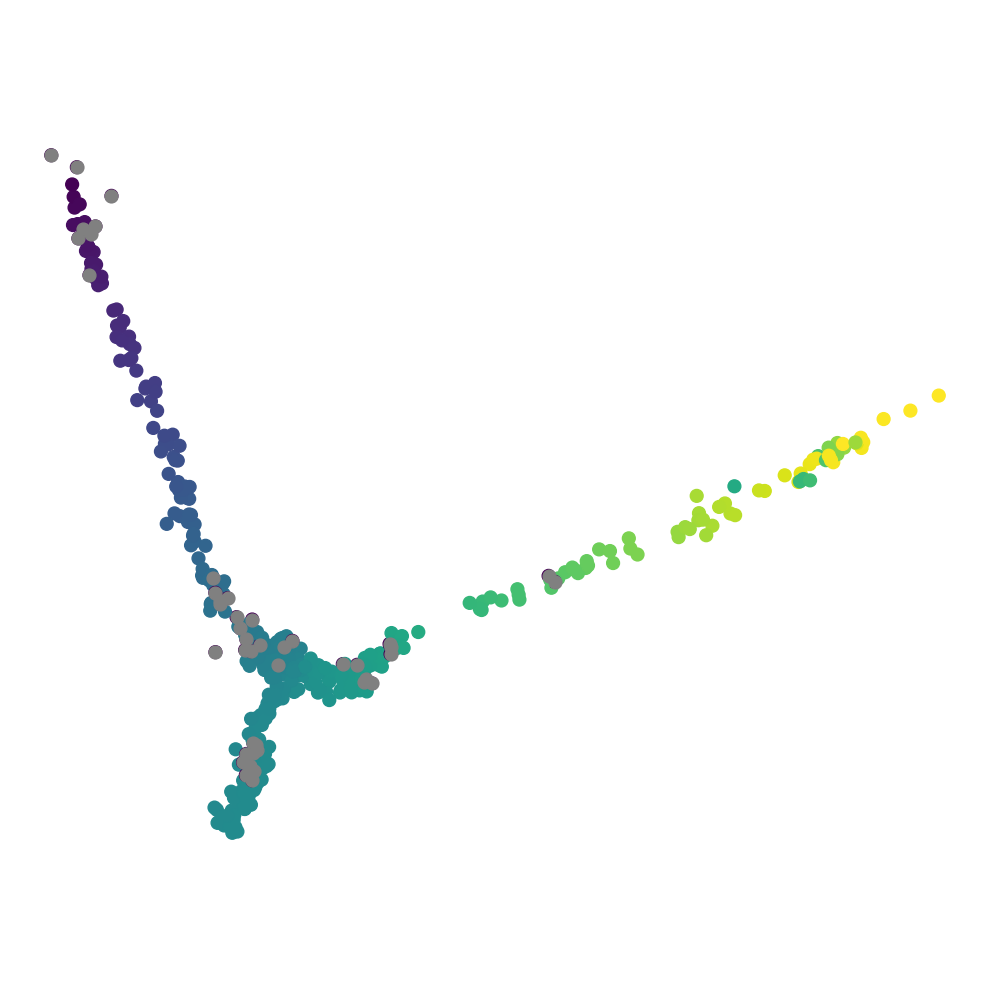

In [38]:
fig = plt.figure(figsize=(10, 10))
plt.scatter(*expressions_2d.T, color=plt.get_cmap('viridis')(np.nan_to_num(pseudotime_vetra)), s=85, zorder=0)
plt.scatter(*expressions_2d[~np.isfinite(pseudotime_vetra)].T, color='gray', s=85, zorder=1)
plt.axis('equal')
plt.axis('off')
fig.tight_layout()